In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install -q tensorflow opencv-python-headless seaborn scikit-learn matplotlib pandas

import os
import cv2
import json
import shutil
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

EXPERIMENT_ID = "E01_BASELINE_SIMPLE_UNET_192"

PROJECT_DIR = Path("/content/drive/MyDrive/Oil Spill/Baseline Detection Model")
RAW_DATASET_DIR = Path("/content/drive/MyDrive/Oil spill Research /Lados Dataset")

SPILL_IDS = {2, 3, 5}

IMG_SIZE = 192
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 30
AUTOTUNE = tf.data.AUTOTUNE

for folder in ["processed", "models", "plots", "results", "logs"]:
    (PROJECT_DIR / folder).mkdir(parents=True, exist_ok=True)

for split in ["train", "valid", "test"]:
    (PROJECT_DIR / "processed" / split / "images").mkdir(parents=True, exist_ok=True)
    (PROJECT_DIR / "processed" / split / "masks").mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Experiment:", EXPERIMENT_ID)
print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DATASET_DIR exists:", RAW_DATASET_DIR.exists())

TensorFlow: 2.20.0
Experiment: E01_BASELINE_SIMPLE_UNET_192
PROJECT_DIR: /content/drive/MyDrive/Oil Spill/Baseline Detection Model
RAW_DATASET_DIR exists: True


In [3]:
def get_image_mask_paths(project_path: Path, split_name: str):
    img_dir = project_path / "processed" / split_name / "images"
    mask_dir = project_path / "processed" / split_name / "masks"

    image_map = {
        Path(f).stem: str(img_dir / f)
        for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    }

    mask_map = {
        Path(f).stem: str(mask_dir / f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith(".png")
    }

    missing_masks = sorted(set(image_map) - set(mask_map))
    missing_images = sorted(set(mask_map) - set(image_map))

    if missing_masks or missing_images:
        print("Images without masks:", len(missing_masks))
        print("Masks without images:", len(missing_images))

    paired_keys = sorted(set(image_map.keys()) & set(mask_map.keys()))

    image_paths = [image_map[k] for k in paired_keys]
    mask_paths = [mask_map[k] for k in paired_keys]

    return image_paths, mask_paths


def convert_split_to_binary(raw_dataset_path: Path, project_path: Path, split_name: str):
    src_path = raw_dataset_path / split_name
    dst_img_path = project_path / "processed" / split_name / "images"
    dst_mask_path = project_path / "processed" / split_name / "masks"

    if not src_path.exists():
        raise FileNotFoundError(f"Missing split folder: {src_path}")

    files = sorted(os.listdir(src_path))

    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png")) and "_mask" not in f.lower()
    ]

    total_images = 0
    total_masks = 0
    empty_masks = 0
    total_oil_pixels = 0
    total_pixels = 0

    for img_file in image_files:
        base = Path(img_file).stem
        mask_file = f"{base}_mask.png"

        img_src = src_path / img_file
        mask_src = src_path / mask_file

        if not mask_src.exists():
            continue

        img = cv2.imread(str(img_src))
        mask = cv2.imread(str(mask_src), cv2.IMREAD_UNCHANGED)

        if img is None or mask is None:
            continue

        if mask.ndim == 3:
            mask = mask[:, :, 0]

        binary_mask = np.isin(mask, list(SPILL_IDS)).astype(np.uint8)

        if binary_mask.sum() == 0:
            empty_masks += 1

        total_oil_pixels += int(binary_mask.sum())
        total_pixels += int(binary_mask.size)

        cv2.imwrite(str(dst_img_path / img_file), img)
        cv2.imwrite(str(dst_mask_path / f"{base}.png"), binary_mask * 255)

        total_images += 1
        total_masks += 1

    oil_ratio = total_oil_pixels / max(total_pixels, 1)

    return {
        "split": split_name,
        "images": total_images,
        "masks": total_masks,
        "empty_masks": empty_masks,
        "oil_pixel_ratio": oil_ratio
    }


summary = []

for split in ["train", "valid", "test"]:
    result = convert_split_to_binary(RAW_DATASET_DIR, PROJECT_DIR, split)
    summary.append(result)
    print(result)

summary_df = pd.DataFrame(summary)
summary_df.to_csv(PROJECT_DIR / "results" / "baseline_processed_dataset_summary.csv", index=False)
summary_df

{'split': 'train', 'images': 2223, 'masks': 2223, 'empty_masks': 892, 'oil_pixel_ratio': 0.2304555885908682}
{'split': 'valid', 'images': 675, 'masks': 675, 'empty_masks': 281, 'oil_pixel_ratio': 0.23352688802083332}
{'split': 'test', 'images': 343, 'masks': 343, 'empty_masks': 134, 'oil_pixel_ratio': 0.2557891649963557}


,split,images,masks,empty_masks,oil_pixel_ratio
0,train,2223,2223,892,0.230456
1,valid,675,675,281,0.233527
2,test,343,343,134,0.255789


Train: 2223 2223
Valid: 675 675
Test : 343 343


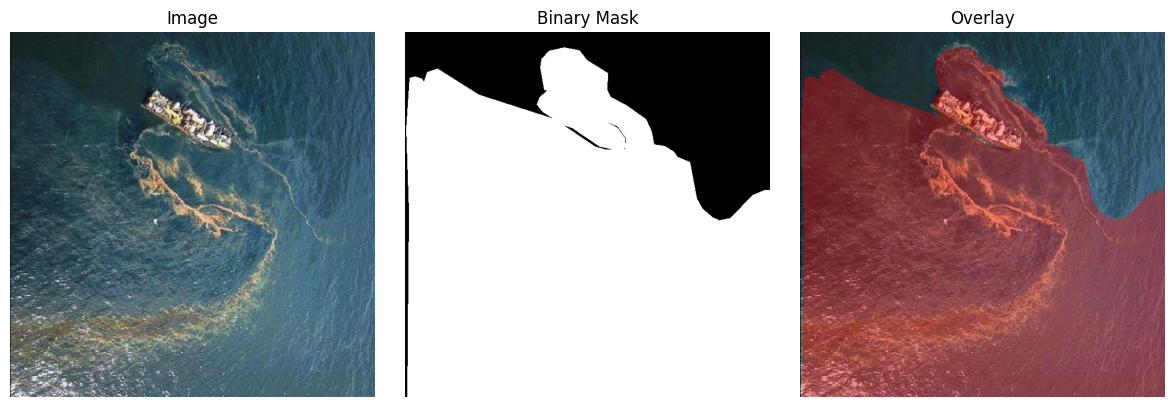

In [4]:
train_image_paths, train_mask_paths = get_image_mask_paths(PROJECT_DIR, "train")
valid_image_paths, valid_mask_paths = get_image_mask_paths(PROJECT_DIR, "valid")
test_image_paths, test_mask_paths = get_image_mask_paths(PROJECT_DIR, "test")

print("Train:", len(train_image_paths), len(train_mask_paths))
print("Valid:", len(valid_image_paths), len(valid_mask_paths))
print("Test :", len(test_image_paths), len(test_mask_paths))


def show_sample(image_path, mask_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask_bin = (mask > 127).astype(np.uint8)

    overlay = img.copy()
    overlay[mask_bin == 1] = [255, 0, 0]
    blended = cv2.addWeighted(img, 0.65, overlay, 0.35, 0)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_bin, cmap="gray")
    plt.title("Binary Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(blended)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


show_sample(train_image_paths[0], train_mask_paths[0])

In [5]:
def read_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image


def read_mask(path):
    mask = tf.io.read_file(path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest")
    mask = tf.cast(mask > 127, tf.float32)
    return mask


def augment_pair(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    image = tf.image.random_brightness(image, max_delta=0.08)
    image = tf.image.random_contrast(image, lower=0.92, upper=1.08)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask


def load_pair(image_path, mask_path):
    image = read_image(image_path)
    mask = read_mask(mask_path)
    return image, mask


def make_dataset(image_paths, mask_paths, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    ds = ds.map(load_pair, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(min(len(image_paths), 512), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment_pair, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_image_paths, train_mask_paths, training=True)
valid_ds = make_dataset(valid_image_paths, valid_mask_paths, training=False)
test_ds = make_dataset(test_image_paths, test_mask_paths, training=False)

for images, masks in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Mask batch:", masks.shape)

Image batch: (8, 192, 192, 3)
Mask batch: (8, 192, 192, 1)


In [6]:
#step 5
SMOOTH = 1e-6

def dice_coef(y_true, y_pred, smooth=SMOOTH):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    return bce + dice_loss(y_true, y_pred)

In [7]:
#step 6
def conv_block(x, filters, dropout=0.0):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    if dropout > 0:
        x = tf.keras.layers.Dropout(dropout)(x)

    return x


def encoder_block(x, filters, dropout=0.0):
    c = conv_block(x, filters, dropout)
    p = tf.keras.layers.MaxPooling2D((2, 2))(c)
    return c, p


def decoder_block(x, skip, filters, dropout=0.0):
    x = tf.keras.layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout)
    return x


def build_baseline_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    s1, p1 = encoder_block(inputs, 32, dropout=0.0)
    s2, p2 = encoder_block(p1, 64, dropout=0.0)
    s3, p3 = encoder_block(p2, 128, dropout=0.05)
    s4, p4 = encoder_block(p3, 256, dropout=0.10)

    b1 = conv_block(p4, 512, dropout=0.15)

    d1 = decoder_block(b1, s4, 256, dropout=0.10)
    d2 = decoder_block(d1, s3, 128, dropout=0.05)
    d3 = decoder_block(d2, s2, 64, dropout=0.0)
    d4 = decoder_block(d3, s1, 32, dropout=0.0)

    outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", padding="same")(d4)

    model = tf.keras.Model(inputs, outputs, name="Baseline_Simple_UNet")
    return model


baseline_model = build_baseline_unet()
baseline_model.summary()
print("Total parameters:", baseline_model.count_params())

Model: "Baseline_Simple_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 192,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 192,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 192, 192,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 192, 192,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 192,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 192, 192,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 96,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 96,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 96,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 48,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        512 │ conv2d_4[0][0]  

 Total params: 7,858,433 (29.98 MB)

 Trainable params: 7,852,545 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

Total parameters: 7858433


In [8]:
#step 7
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name="iou"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
    ]
)

In [9]:
#step 8
baseline_model_path = PROJECT_DIR / "models" / "baseline_unet_model.keras"
training_log_path = PROJECT_DIR / "logs" / "baseline_training_log.csv"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(baseline_model_path),
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(str(training_log_path))
]

history = baseline_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Saved baseline model:", baseline_model_path)
print("Saved training log:", training_log_path)

Epoch 1/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7217 - dice_coef: 0.3938 - iou: 0.3007 - loss: 1.1676 - precision: 0.4732 - recall: 0.4526
Epoch 1: val_dice_coef improved from None to 0.26937, saving model to /content/drive/MyDrive/Oil Spill/Baseline Detection Model/models/baseline_unet_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil Spill/Baseline Detection Model/models/baseline_unet_model.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 129s 291ms/step - accuracy: 0.7443 - dice_coef: 0.3800 - iou: 0.3156 - loss: 1.1422 - precision: 0.4518 - recall: 0.5114 - val_accuracy: 0.7447 - val_dice_coef: 0.2694 - val_iou: 0.2246 - val_loss: 1.2914 - val_precision: 0.4360 - val_recall: 0.3167 - learning_rate: 1.0000e-04
Epoch 2/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7642 - dice_coef: 0.4480 - iou: 0.3719 - loss: 1.0500 - precision: 0.5549 - recall: 0.5328
Epoch 2: val_dice_coef improved from 0.26937 to 0.36398, saving model to /content/drive/

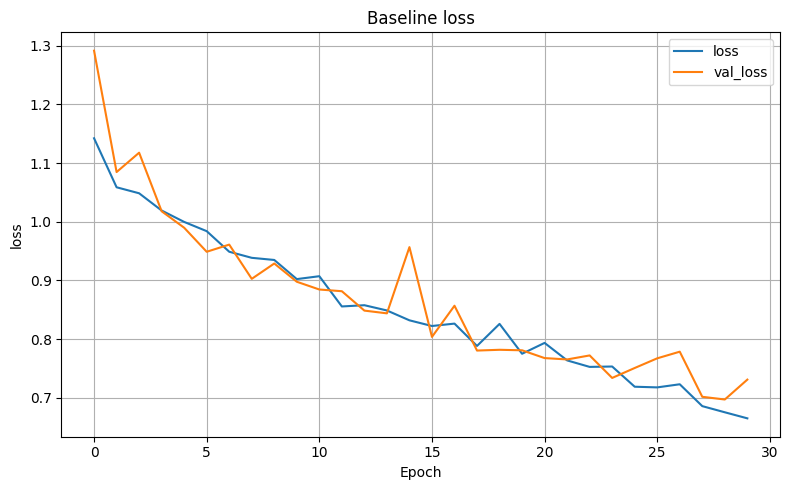

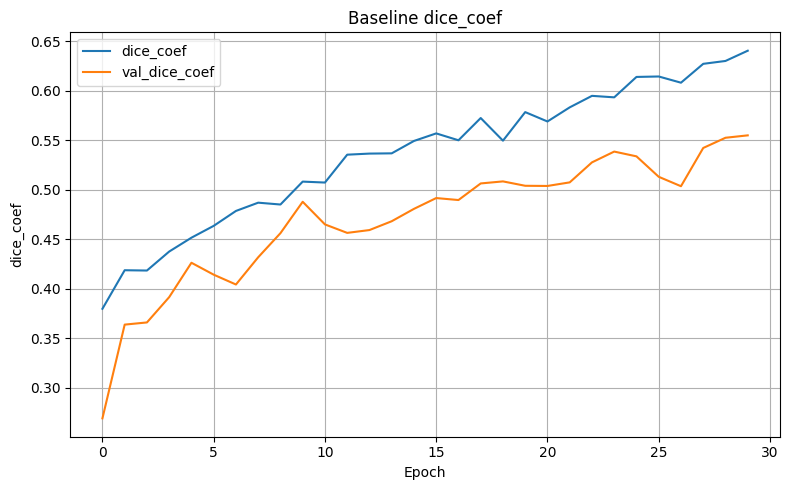

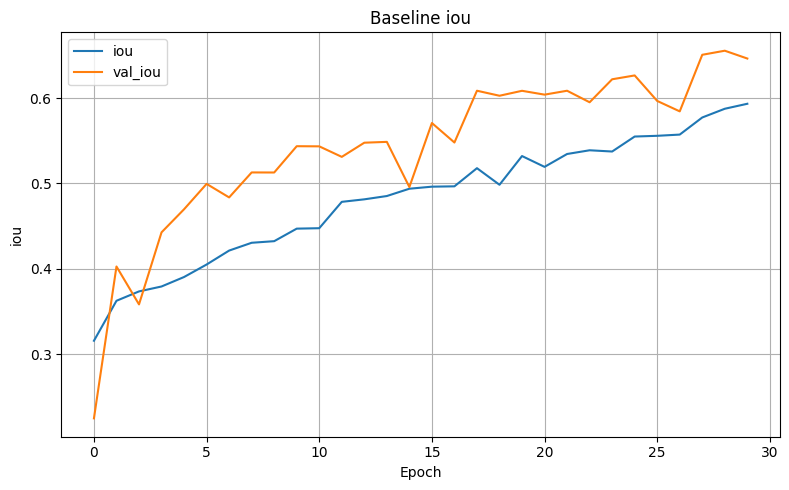

In [10]:
#step 9
history_df = pd.read_csv(training_log_path)

history_df.to_csv(PROJECT_DIR / "results" / "baseline_training_history.csv", index=False)

def plot_curve(metric, save_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df[metric], label=metric)

    val_metric = "val_" + metric
    if val_metric in history_df.columns:
        plt.plot(history_df[val_metric], label=val_metric)

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Baseline {metric}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / "plots" / save_name, dpi=200)
    plt.show()

plot_curve("loss", "baseline_loss_curve.png")
plot_curve("dice_coef", "baseline_dice_curve.png")
plot_curve("iou", "baseline_iou_curve.png")

In [11]:
#step 10
best_baseline_model = tf.keras.models.load_model(
    baseline_model_path,
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef
    }
)

results = best_baseline_model.evaluate(test_ds, verbose=1)
metrics = dict(zip(best_baseline_model.metrics_names, results))

print("=== Baseline Test Metrics at Threshold 0.5 ===")
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

with open(PROJECT_DIR / "results" / "baseline_test_metrics_threshold_0_5.json", "w") as f:
    json.dump(metrics, f, indent=2)

43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step - accuracy: 0.8829 - dice_coef: 0.5753 - iou: 0.6506 - loss: 0.7230 - precision: 0.7336 - recall: 0.8518
=== Baseline Test Metrics at Threshold 0.5 ===
loss: 0.722998
compile_metrics: 0.575330


In [ ]:
#step 11
def gather_predictions(model, dataset):
    all_true = []
    all_prob = []

    for images, masks in dataset:
        preds = model.predict(images, verbose=0)

        all_true.append(masks.numpy().astype(np.uint8).flatten())
        all_prob.append(preds.flatten())

    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)

    return y_true, y_prob


def compute_metrics_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp

    def safe_div(a, b):
        return float(a / b) if b else 0.0

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": safe_div(tp + tn, total),
        "precision": safe_div(tp, tp + fp),
        "recall": safe_div(tp, tp + fn),
        "iou": safe_div(tp, tp + fp + fn),
        "dice": safe_div(2 * tp, 2 * tp + fp + fn),
    }


y_true, y_prob = gather_predictions(best_baseline_model, test_ds)

thresholds = np.arange(0.30, 0.86, 0.02)
threshold_results = []

for th in thresholds:
    y_pred = (y_prob > th).astype(np.uint8)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    m = compute_metrics_from_cm(cm)
    m["threshold"] = float(th)
    threshold_results.append(m)

threshold_df = pd.DataFrame(threshold_results)
threshold_df.to_csv(PROJECT_DIR / "results" / "baseline_threshold_sweep_results.csv", index=False)

best_row = threshold_df.loc[threshold_df["dice"].idxmax()]
best_threshold = float(best_row["threshold"])

print("Best threshold:", best_threshold)
print(best_row)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["dice"], label="Dice", marker="o")
plt.plot(threshold_df["threshold"], threshold_df["iou"], label="IoU", marker="o")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Baseline Threshold Sweep")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "plots" / "baseline_threshold_sweep.png", dpi=200)
plt.show()

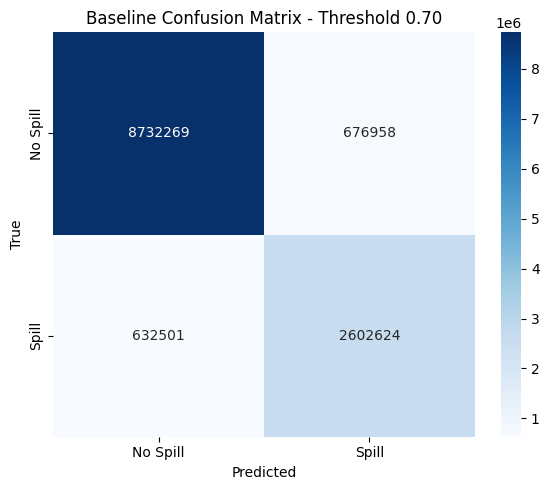

In [13]:
#step 12 confution matrics


best_pred = (y_prob > best_threshold).astype(np.uint8)
cm = confusion_matrix(y_true, best_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["True No Spill", "True Spill"],
    columns=["Pred No Spill", "Pred Spill"]
)
cm_df.to_csv(PROJECT_DIR / "results" / "baseline_confusion_matrix.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Spill", "Spill"],
    yticklabels=["No Spill", "Spill"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Baseline Confusion Matrix - Threshold {best_threshold:.2f}")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "plots" / "baseline_confusion_matrix.png", dpi=200)
plt.show()

In [ ]:
#step 13
qual_dir = PROJECT_DIR / "plots" / "baseline_sample_predictions"
qual_dir.mkdir(parents=True, exist_ok=True)

for images, masks in test_ds.take(1):
    preds = best_baseline_model.predict(images, verbose=0)
    preds_bin = (preds > best_threshold).astype(np.float32)

    for i in range(min(5, images.shape[0])):
        img = images[i].numpy()
        true_mask = masks[i].numpy().squeeze()
        pred_mask = preds_bin[i].squeeze()

        overlay = img.copy()
        overlay[pred_mask == 1] = [1.0, 0.0, 0.0]
        blended = 0.65 * img + 0.35 * overlay

        plt.figure(figsize=(14, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(blended)
        plt.title("Overlay")
        plt.axis("off")

        plt.tight_layout()
        save_path = qual_dir / f"baseline_prediction_{i+1}.png"
        plt.savefig(save_path, dpi=200)
        plt.show()

print("Saved sample predictions to:", qual_dir)

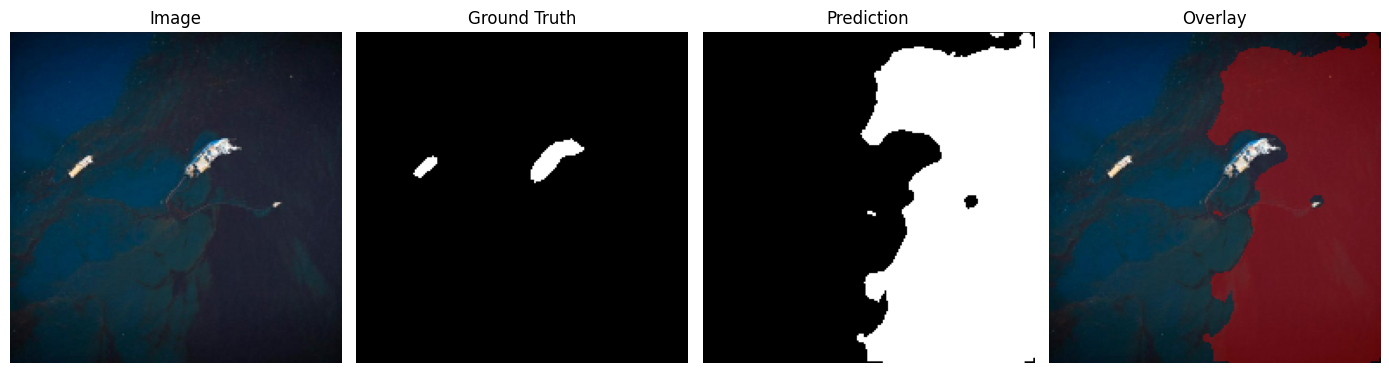

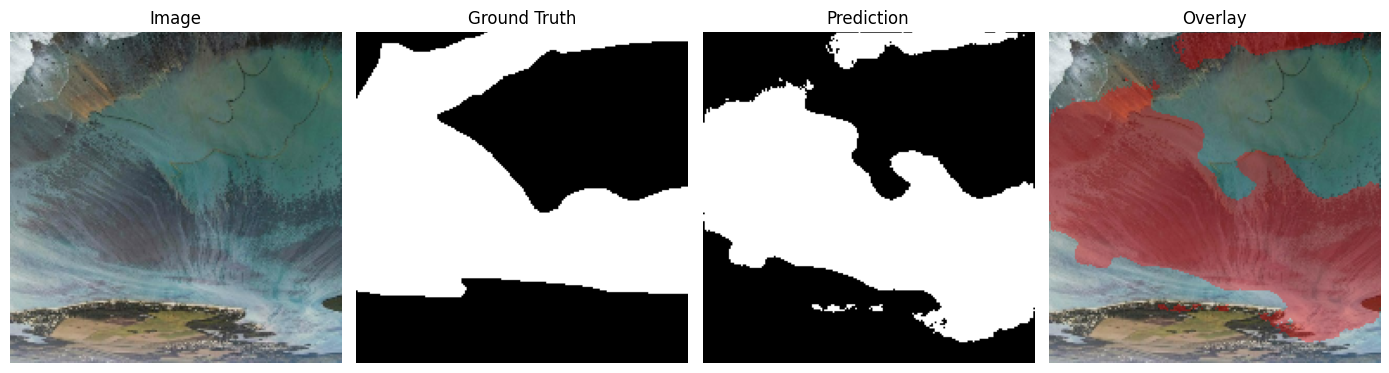

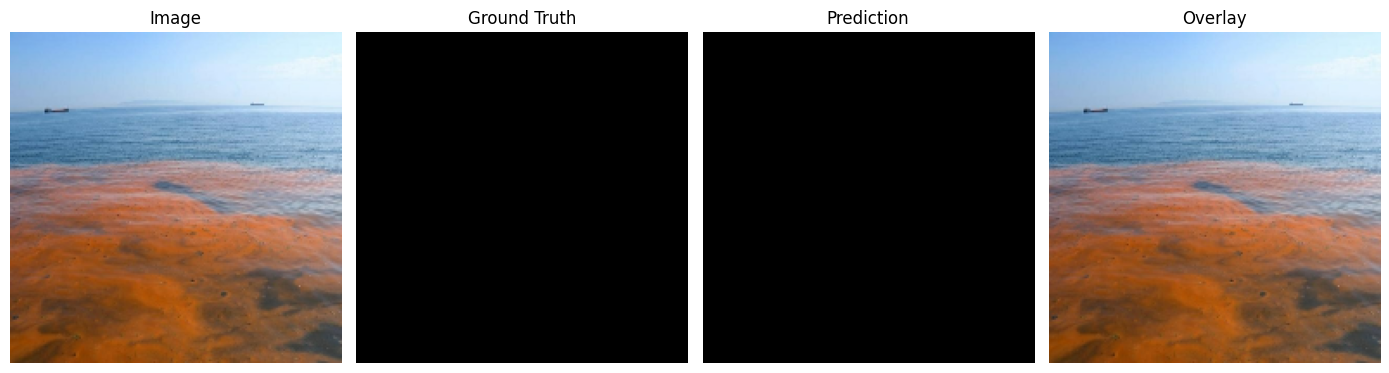

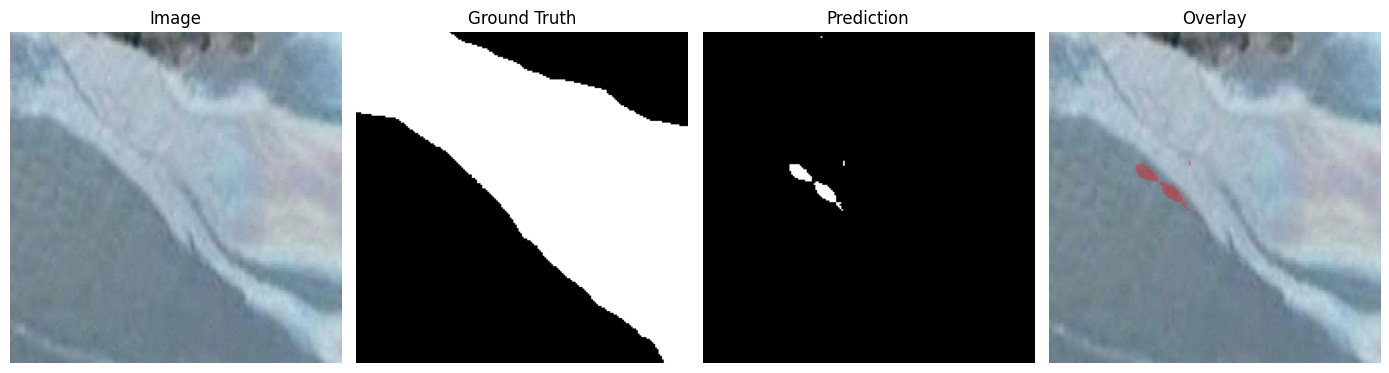

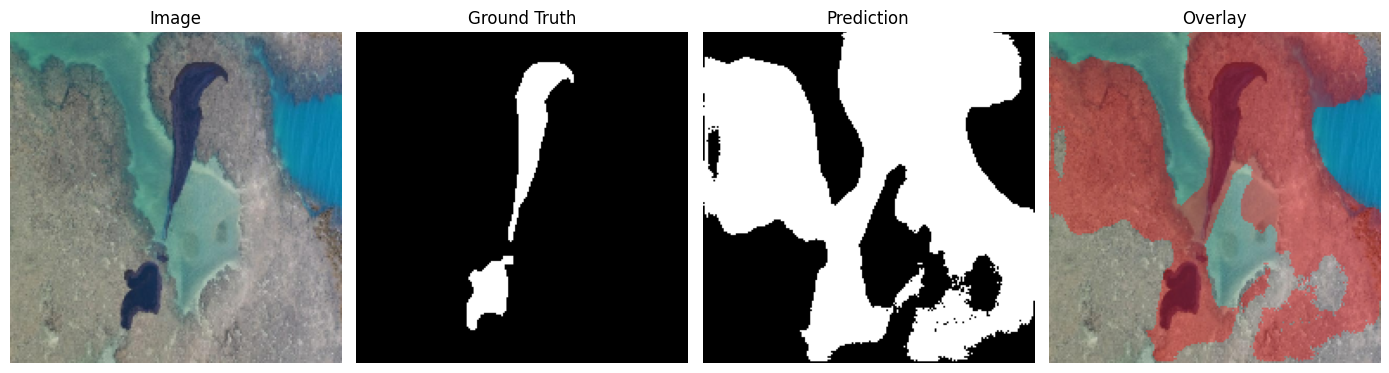

Saved sample predictions to: /content/drive/MyDrive/Oil Spill/Baseline Detection Model/plots/baseline_sample_predictions


In [15]:
#step 14
qual_dir = PROJECT_DIR / "plots" / "baseline_sample_predictions"
qual_dir.mkdir(parents=True, exist_ok=True)

for images, masks in test_ds.take(1):
    preds = best_baseline_model.predict(images, verbose=0)
    preds_bin = (preds > best_threshold).astype(np.float32)

    for i in range(min(5, images.shape[0])):
        img = images[i].numpy()
        true_mask = masks[i].numpy().squeeze()
        pred_mask = preds_bin[i].squeeze()

        overlay = img.copy()
        overlay[pred_mask == 1] = [1.0, 0.0, 0.0]
        blended = 0.65 * img + 0.35 * overlay

        plt.figure(figsize=(14, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(blended)
        plt.title("Overlay")
        plt.axis("off")

        plt.tight_layout()
        save_path = qual_dir / f"baseline_prediction_{i+1}.png"
        plt.savefig(save_path, dpi=200)
        plt.show()

print("Saved sample predictions to:", qual_dir)